Primero analicemos un conjunto de imágenes simples que consiste solamente en imágenes de dígitos escritos a mano en blanco y negro de tamaño 28x28 pixels en 10 categorías del 0-9.

Usaremos el conjunto de datos MNIST que contiene 60,000 imágenes, más 10,000 imágenes de prueba.

In [1]:
from keras.datasets import mnist

(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

2025-10-26 13:33:17.232034: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2025-10-26 13:33:20.947002: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2025-10-26 13:33:20.977741: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-10-26 13:33:27.347403: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [2]:
#El lote de imagenes es  un array de números enteros
train_images.dtype, train_images.shape

(dtype('uint8'), (60000, 28, 28))

In [3]:
#Las etiquetas es un arreglo que contiene el número correspondiente a cada imagen
len(train_labels), train_labels.dtype

(60000, dtype('uint8'))

In [4]:
train_labels, train_images[0]

(array([5, 0, 4, ..., 5, 6, 8], dtype=uint8),
 array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,
          18,  18,  18, 126, 136, 175,  

<function matplotlib.pyplot.show(close=None, block=None)>

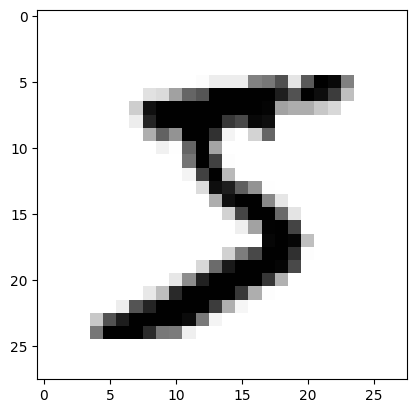

In [5]:
import matplotlib.pyplot as plt

#Veamos como se ven los ejemplos
plt.imshow(train_images[0], cmap=plt.cm.binary)
plt.show

Vemos que la codificación de la imágen muestra en negro al 0 y en blanco al 255, por lo que para normalizar podríamos solo dividir entre 255.

In [6]:
#Convertimos la imágen al formato de tensor normalizado
import torch

train_images_t = torch.tensor(train_images)/255
train_labels_t = torch.tensor(train_labels)
test_images_t = torch.tensor(test_images[0:500])/255
test_labels_t = torch.tensor(test_labels[0:500])

train_images_t.dtype, train_images_t.shape, train_labels_t.shape
#Esto tarda un rato

(torch.float32, torch.Size([60000, 28, 28]), torch.Size([60000]))

Sin embargo, necesitamos convertir este arreglo de tal forma que las imagenes en ves de verse como matrices se vean como renglones, en particular vectores renglon, para esto podemos recurrir a la siguiente forma:

In [7]:
len(train_labels_t)

60000

In [8]:
#Cambiamos su forma a vector las imágenes
tr_img_v = torch.reshape(train_images_t, (60000, 28*28))
test_img_v = torch.reshape(test_images_t, (500, 28*28))
tr_img_v, tr_img_v.shape

(tensor([[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]]),
 torch.Size([60000, 784]))

En cuanto a los datos de salida, estos son datos numéricos claro, pero la información importante no está ni en su valor ni en su orden respecto a los otros, por lo que los trataremos como variables categóricas (aunque se puede siempre dejar igual)

In [9]:
#Creamos el tensor de etiquetas
tr_img_t = tr_img_v[0:1000]
tr_labels_t = train_labels_t[0:1000]

one_hot_labels = torch.zeros(len(tr_labels_t),10)
one_hot_testlabels = torch.zeros(len(test_labels_t),10)

#Codificamos la información en cada renglón
for i,j in enumerate(tr_labels_t):
    j = int(j)
    one_hot_labels[i,j] = 1.0

for i,j in enumerate(test_labels_t):
    j = int(j)
    one_hot_testlabels[i,j] = 1.0

tr_labels = one_hot_labels
test_labels = one_hot_testlabels
tr_labels

tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [1., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        ...,
        [1., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.]])

Usaremos ahora otro tipo de función de activación llamada RELU pues esto nos permite quitarle importancia los valores negativos y así quedarnos con valores siempre positivos. Además, como la respuesta final está acotada entre los valores de 0-9, usaremos la función regularizadora softmax en la última capa.

Como es usual, los tensores de entrada puden tener dimensiones a lo largo de las cuales codifican las probabilidades y otras en las cuales no, esto nos requier especificar la dimensio a través de la cual la función será aplicada

In [11]:
#El módulo nn ya cuenta con softmax 
import torch.nn as nn

softmax = nn.Softmax(dim=1)      #Localculara renglon por renglon

x = torch.tensor([[1.0, 2.0, 3.0],
                  [1.0, 2.0, 3.0]])

softmax(x)

tensor([[0.0900, 0.2447, 0.6652],
        [0.0900, 0.2447, 0.6652]])

In [12]:
#Procedemos a construir un modelo
import torch.nn as nn
from collections import OrderedDict

seq_model = nn.Sequential(OrderedDict([
    ('hidden_linear', nn.Linear(784, 40)),
    ('hidden_activation', nn.ReLU()),
    ('output_linear', nn.Linear(40,10)),
    ('output_activation', nn.Softmax(dim=1))
    ]))

seq_model

Sequential(
  (hidden_linear): Linear(in_features=784, out_features=40, bias=True)
  (hidden_activation): ReLU()
  (output_linear): Linear(in_features=40, out_features=10, bias=True)
  (output_activation): Softmax(dim=1)
)

Vamos a analizar como se comporta el entrenamiento en cuanto a la presición para predecir imágenes y no ya en cuanto a el error cuadrático médio, esto nos dará quizas una mejor idea de qe tan bueno es nuestro modelo.

In [13]:
def training_loop(n_epochs, optimizer, model, loss_fn, tr_img_t, tr_labels, test_img_v, test_labels):
    for epoch in range(1, n_epochs +1):
        correct_cnt = 0
        test_correct_cnt = 0
    
        labels_p = model(tr_img_t)
        train_loss = loss_fn(labels_p,tr_labels)

        labels_pv = model(test_img_v)
        val_loss = loss_fn(labels_pv,test_labels)

        optimizer.zero_grad()
        train_loss.backward()
        optimizer.step()

        if epoch % 10 == 0:
            for k in range(1000):
                test_correct_cnt += torch.argmax(seq_model(tr_img_t)[k]) == torch.argmax(tr_labels[k])
                
            for k in range(500):
                correct_cnt += torch.argmax(seq_model(test_img_v)[k]) == torch.argmax(test_labels[k])
                
            
            print("\n"+ "I:" + str(epoch) + \
                             " Test-Acc:"+str(test_correct_cnt/float(1000))+\
                             " Train-Acc:" + str(correct_cnt/500))

In [14]:
import torch.optim as optim 

optimizer = optim.SGD(seq_model.parameters(), lr=7e-1 )

training_loop(
    n_epochs = 300,
    optimizer = optimizer,
    model = seq_model,
    loss_fn = nn.MSELoss(),
    tr_img_t = tr_img_t,
    tr_labels = tr_labels,
    test_img_v = test_img_v,
    test_labels = test_labels)


I:10 Test-Acc:tensor(0.1190) Train-Acc:tensor(0.1280)

I:20 Test-Acc:tensor(0.1670) Train-Acc:tensor(0.1580)

I:30 Test-Acc:tensor(0.2230) Train-Acc:tensor(0.1980)

I:40 Test-Acc:tensor(0.2710) Train-Acc:tensor(0.2540)

I:50 Test-Acc:tensor(0.3320) Train-Acc:tensor(0.2760)

I:60 Test-Acc:tensor(0.4100) Train-Acc:tensor(0.3120)

I:70 Test-Acc:tensor(0.5040) Train-Acc:tensor(0.3680)

I:80 Test-Acc:tensor(0.5780) Train-Acc:tensor(0.4440)

I:90 Test-Acc:tensor(0.6280) Train-Acc:tensor(0.5000)

I:100 Test-Acc:tensor(0.6600) Train-Acc:tensor(0.5280)

I:110 Test-Acc:tensor(0.6570) Train-Acc:tensor(0.5480)

I:120 Test-Acc:tensor(0.6510) Train-Acc:tensor(0.5480)

I:130 Test-Acc:tensor(0.6480) Train-Acc:tensor(0.5540)

I:140 Test-Acc:tensor(0.6390) Train-Acc:tensor(0.5480)

I:150 Test-Acc:tensor(0.6460) Train-Acc:tensor(0.5620)

I:160 Test-Acc:tensor(0.6410) Train-Acc:tensor(0.5720)

I:170 Test-Acc:tensor(0.6370) Train-Acc:tensor(0.5800)

I:180 Test-Acc:tensor(0.6410) Train-Acc:tensor(0.5840)



9.0

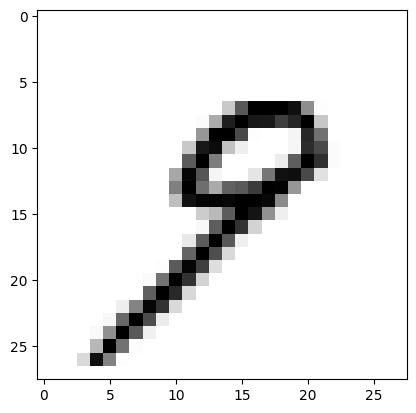

In [34]:
#Veamos como se ven la preiccion con los datos de entrenamiento
import random as rand

n = rand.randint(0,1000)
plt.imshow(train_images[n], cmap=plt.cm.binary)
plt.show

pred = seq_model(tr_img_t[n].unsqueeze(0))
float(torch.argmax(pred))

Pasemos ahora a un problema más complejo en el cula ahora utilizaremos no solo imágenes con más pixeles, sino que estas representan objetos en sí y las imágenes tienen color.

In [35]:
from torchvision import datasets

#Descargamos la base de datos CIFAR10
data_path = '../data-unversioned'
cifar10 = datasets.CIFAR10(data_path, train=True, download=True)
cifar10_val = datasets.CIFAR10(data_path, train=False, download=True)

Files already downloaded and verified
Files already downloaded and verified


In [36]:
type(cifar10).__mro__

(torchvision.datasets.cifar.CIFAR10,
 torchvision.datasets.vision.VisionDataset,
 torch.utils.data.dataset.Dataset,
 typing.Generic,
 object)

In [37]:
len(cifar10)

50000

In [38]:
# Definimos nombres de clase nombres de clase
class_names = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]

# Tomar un ejemplo
img, label = cifar10[99]
img, label, class_names[label]

(<PIL.Image.Image image mode=RGB size=32x32>, 1, 'automobile')

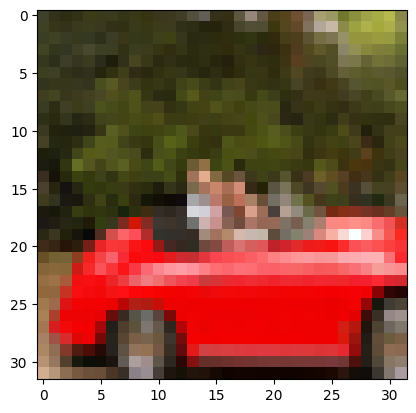

In [39]:
#Mostramos la imagen correspondiente
plt.imshow(img)
plt.show()

Puesto que esta base de datos es afin a torch podemos usar una de sus herramientas como transforms para convertir la imagen tipo PIL en un tensor. No solo sive para realizar transformaciones en tensores sino que también para hacer pequeñas modificaciones en la imagen.

In [40]:
from torchvision import transforms
dir(transforms)

['AugMix',
 'AutoAugment',
 'AutoAugmentPolicy',
 'CenterCrop',
 'ColorJitter',
 'Compose',
 'ConvertImageDtype',
 'ElasticTransform',
 'FiveCrop',
 'GaussianBlur',
 'Grayscale',
 'InterpolationMode',
 'Lambda',
 'LinearTransformation',
 'Normalize',
 'PILToTensor',
 'Pad',
 'RandAugment',
 'RandomAdjustSharpness',
 'RandomAffine',
 'RandomApply',
 'RandomAutocontrast',
 'RandomChoice',
 'RandomCrop',
 'RandomEqualize',
 'RandomErasing',
 'RandomGrayscale',
 'RandomHorizontalFlip',
 'RandomInvert',
 'RandomOrder',
 'RandomPerspective',
 'RandomPosterize',
 'RandomResizedCrop',
 'RandomRotation',
 'RandomSolarize',
 'RandomVerticalFlip',
 'Resize',
 'TenCrop',
 'ToPILImage',
 'ToTensor',
 'TrivialAugmentWide',
 '__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__path__',
 '__spec__',
 '_functional_pil',
 '_functional_tensor',
 '_presets',
 'autoaugment',
 'functional',
 'transforms']

In [41]:
#Hacemos una función solo para no escribir todo el comando y para ver su efecto
to_tensor = transforms.ToTensor()
img_t = to_tensor(img)
img_t.shape

torch.Size([3, 32, 32])

In [42]:
#Vamos a aplicarlo a todas las imagenes a la vez
tensor_cifar10 = datasets.CIFAR10(data_path, train=True, download=False, transform=transforms.ToTensor())

In [43]:
#Accediendo a cada elemento veremos que ahora es tipo tensor
img_t, _ = tensor_cifar10[99]
type(img_t), img_t.shape

(torch.Tensor, torch.Size([3, 32, 32]))

Hay que notar aquí que, mientras la imágen original las intensidades de cada color estaban formato 0-255, ahora al transformarlo a tensor automáticamente normalizó la imagen con valores de 0-1

In [44]:
img_t.min(), img_t.max()

(tensor(0.), tensor(1.))

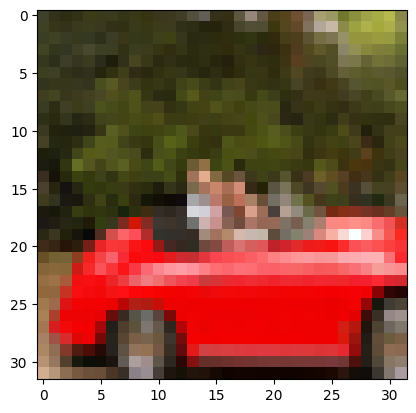

In [45]:
#Veamos que python la interpreta como la misma imagen
plt.imshow(img_t.permute(1,2,0))     #Veamos que tenemos que permutar porque el formato original es HXwXC
plt.show()

Ahora que ya hemos visto las funciones de activación en acción así como la normalización podemos hablar en mayor profundidad por qué son importantes más alla de ayudar en las características no lineales del modelado. Estas además ayudan a prevenir el sobre ajuste o memorización de la red restando importancia a ciertas neuronas y dándosela a otras. Más aun, cuando se escogen funciones de activacióon que son lineales cerca de 0 o -1 o 1, y mantienen los datos en un rango similar como tanh o relu, singifica que es más probable que las neuronas cerca de 0 tengan gradiente no nulo y así aprendan más rápidamente, por eso es importante la normalización tambien.

Adicionalmente, la normalización de cada canal de tal forma que cada uno tenga la misma distribución asegurará que la información de los canales puede ser mezclada y actualizada a través de SGD con el mismo learning rate.

In [46]:
#En lugar de normalizar como lo hicimos en el caso de la red neuronal de regresión usaremos transforms
#Primero formamos el bloque de imagenes como tensor
imgs =  torch.stack([img_t for img_t, _ in tensor_cifar10], dim=3)
imgs.shape
#El proceso durará un rato

torch.Size([3, 32, 32, 50000])

In [47]:
#Calculamos ahora facilmente el promedio de cada canal
imgs.view(3, -1).mean(dim=1)
#Aquí cada imagen se convirtió en un vector con 3 canales y promediara sobre cada canal

tensor([0.4914, 0.4822, 0.4465])

In [48]:
#Calculamos la desviación estandar
imgs.view(3,-1).std(dim=1)

tensor([0.2470, 0.2435, 0.2616])

In [49]:
#Ahora normalizamos con Normalize
transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))

Normalize(mean=(0.4914, 0.4822, 0.4465), std=(0.247, 0.2435, 0.2616))

In [50]:
#Y nuevamente importamos los datos de cifar usando Compose para aplicar varios procedimientos
transformed_cifar10 = datasets.CIFAR10(data_path, train=True, download=False, transform=transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2470, 0.2435, 0.2616))
]))
transformed_cifar10_val = datasets.CIFAR10(data_path, train=False, download=False, transform=transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2470, 0.2435, 0.2616))
]))

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


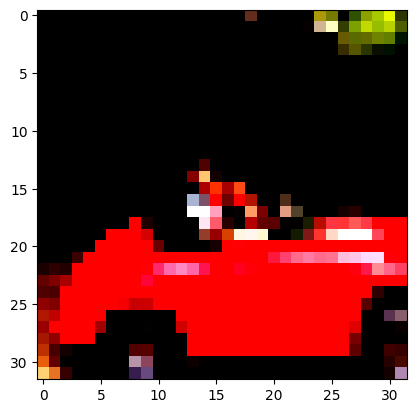

In [51]:
#La imagen ahora transformada ya no es la que era antes debido a esta normalización
img_t, _ = transformed_cifar10[99]
plt.imshow(img_t.permute(1,2,0))
plt.show()

A diferencia del problema anterior, ahora lo que haremos será solo tomar las imágenes de aves y de aviones y vamos a hacer una red neuronal que las distinga una de otra.

In [52]:
#Armamos el set de datos
label_map = {0:0, 2:1}           #Esto reetiqueta los elementos en cifar10 (estos ya estaban etiquetados)
class_names = ['airplane', 'bird']
cifar2 = [(img, label_map[label])           #Es un arreglo de tuplas no ordenado solo es un filtro
          for img, label in transformed_cifar10
          if label in [0, 2]]
cifar2_val = [(img, label_map[label])
              for img, label in transformed_cifar10_val
              if label in [0, 2]]
#Esto toma un ratito porque lo hace con las 50000 imágenes

In [53]:
imge, lbl = cifar2[0]
print(lbl) #El label nos dice que objeto es, si un avion 0 o un ave 1

1


In [54]:
len(cifar2)            #Esta es la cantidad de imagenes de aviones y aves

10000

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


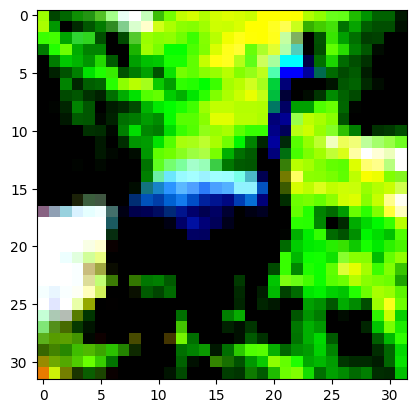

In [55]:
#Veamos una imagen de ave o del label 0
img, _ = cifar2[0]
plt.imshow(img.permute(1, 2, 0))
plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


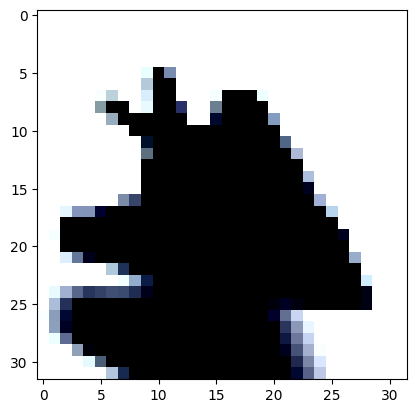

In [56]:
#Buscamos una imagen de avion
i = 0
for _, lbl in cifar2:
    if lbl == 0:
        break
    else:
        i += 1

img, _ = cifar2[i]

plt.imshow(img.permute(1, 2, 0))
plt.show()

In [57]:
#Escribimos el modelo
import torch.nn as nn

n_out = 2         #Es el número de parámetros de salida ave o avión

model = nn.Sequential(
        nn.Linear(3072, 512),           #Va a entrar un vector de 3x32x32
        nn.Tanh(),                      #La capa oculta tiene 512
        nn.Linear(512, n_out),
        nn.Softmax(dim=1))

In [58]:
#Para evaluar en el modelo primero debemos convertir la imagen en un vector para eso hacemos
img_batch = img.view(-1).unsqueeze(0)
img.shape, img.view(-1).shape, img_batch.shape
#Como vemos .view(-1) nos hace el trabajo de convertir la imagen tensor en un vector y unsqueeze lo hace renglon

(torch.Size([3, 32, 32]), torch.Size([3072]), torch.Size([1, 3072]))

In [59]:
out = model(img_batch)
out
#Lo que nos da una distribución de probabilidad entre las dos opciones que sumadas da 1

tensor([[0.4174, 0.5826]], grad_fn=<SoftmaxBackward0>)

In [60]:
#Nuevamente para saber qué valor predie, tomaremos el de mayor probabilidad
_, index = torch.max(out, dim=1)
index

tensor([1])

Sin embargo, a diferencia de como entrenamos la red neuronal que reconoce dígitos, ahora buscamos que la función de error "castigue" las clasificaciones erroneas y no su cercania a los valores de probabilidad buscados. Esta cantidad es llamada verosimilitud o likelihood. En otras palabras buscamos una función de error que sea muy grande cuando la verosimilitud sea baja: asi que las alternativas tienen mayor probabilidad. E inversamente es baja cuando la verosimilitud es baja. La función es llamada negative log likelihood (NLL).

In [61]:
#En torch se escribe con nn esta función de error así que el modelo 
model = nn.Sequential(
    nn.Linear(3072, 512),
    nn.Tanh(),
    nn.Linear(512, 2),
    nn.LogSoftmax(dim=1))      #Cambiamos a LogSoftmax porque nos da mayor estabilidad en los cálculos

#Definimos la función de error
loss = nn.NLLLoss()

In [62]:
img, label = cifar2[0]

out = model(img.view(-1).unsqueeze(0))
print(out)

loss(out, torch.tensor([label]))

tensor([[-1.2156, -0.3517]], grad_fn=<LogSoftmaxBackward0>)


tensor(0.3517, grad_fn=<NllLossBackward0>)

In [63]:
#Pasamos a la función de entrenamiento
def training_loop(n_epochs, optimizer, model, loss_fn):
    for epoch in range(1, n_epochs +1):
        for img, label in cifar2:
            out = model(img.view(-1).unsqueeze(0))
            loss = loss_fn(out, torch.tensor([label]))
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            print("Epoch: %d, Loss: %f" % (epoch, float(loss)))

In [64]:
#El entrenamiento
optimizer = optim.SGD(model.parameters(), lr=1e-2)

training_loop(
    n_epochs = 100,
    optimizer = optimizer,
    model = model,
    loss_fn = nn.NLLLoss())

Epoch: 1, Loss: 0.351741
Epoch: 1, Loss: 1.489082
Epoch: 1, Loss: 2.419183
Epoch: 1, Loss: 0.011342
Epoch: 1, Loss: 0.201981
Epoch: 1, Loss: 0.324058
Epoch: 1, Loss: 4.201169
Epoch: 1, Loss: 5.260367
Epoch: 1, Loss: 0.265189
Epoch: 1, Loss: 3.569248
Epoch: 1, Loss: 0.025475
Epoch: 1, Loss: 3.876928
Epoch: 1, Loss: 0.028063
Epoch: 1, Loss: 1.975181
Epoch: 1, Loss: 0.235665
Epoch: 1, Loss: 0.167020
Epoch: 1, Loss: 3.553857
Epoch: 1, Loss: 0.591420
Epoch: 1, Loss: 0.198609
Epoch: 1, Loss: 0.101611
Epoch: 1, Loss: 3.164418
Epoch: 1, Loss: 0.118944
Epoch: 1, Loss: 1.146736
Epoch: 1, Loss: 1.630666
Epoch: 1, Loss: 0.369943
Epoch: 1, Loss: 0.927834
Epoch: 1, Loss: 2.000782
Epoch: 1, Loss: 0.133058
Epoch: 1, Loss: 1.202655
Epoch: 1, Loss: 0.111548
Epoch: 1, Loss: 0.318911
Epoch: 1, Loss: 0.270852
Epoch: 1, Loss: 0.643212
Epoch: 1, Loss: 0.106593
Epoch: 1, Loss: 2.418435
Epoch: 1, Loss: 0.026141
Epoch: 1, Loss: 0.730879
Epoch: 1, Loss: 0.228583
Epoch: 1, Loss: 0.416735
Epoch: 1, Loss: 0.035389


KeyboardInterrupt: 

El problema es que la función de entrenamiento actualiza el error con cada imagen en cada paso, pero hay muchísimas imágenes, lo que no es muy eficiente, pues alarga el proceso. La idea es, no usar todos los datos como hicimos con modelos anteriores y tampoco usar uno por uno en el proceso de aprendizaje, sino dividir todo el set de datos en paquetes de un tamaño adecuado tal que el proceso de aprendizaje se haga con cada paquete (que acumulen el gradiente y posteriormente actualicen el modelo

Resulta que usar gradientes estimados sobre paquetes, las cuales son aproximaciones más pobres que el gradiente estimado con todo el set, ayuda a la convergencia y previene que el proceso de optimización se atasque en mínimos locales que se encuentre en el proceso. El tamaño del paquete es un hiperparámetro asi como la velocidad de entrenamiento.

In [65]:
#Usamo torch para crear estos paquetes
train_loader = torch.utils.data.DataLoader(cifar2, batch_size=64, shuffle=True)

In [66]:
#Cambiamos la función de entrenamiento
def training_loop(n_epochs, optimizer, model, loss_fn):
    for epoch in range(1, n_epochs +1):
        for imgs, labels in train_loader:
            batch_size = imgs.shape[0]
            outputs = model(imgs.view(batch_size,-1))
            loss = loss_fn(outputs, labels)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
        
        print("Epoch: %d, Loss: %f" % (epoch, float(loss)))

In [67]:
#Ahora entrenamos
training_loop(
    n_epochs = 100,
    optimizer = optimizer,
    model = model,
    loss_fn = nn.NLLLoss())

Epoch: 1, Loss: 0.196324
Epoch: 2, Loss: 0.235691
Epoch: 3, Loss: 0.547070
Epoch: 4, Loss: 0.199250
Epoch: 5, Loss: 0.449325
Epoch: 6, Loss: 0.182538
Epoch: 7, Loss: 0.686206
Epoch: 8, Loss: 0.328479
Epoch: 9, Loss: 0.254176
Epoch: 10, Loss: 0.785189
Epoch: 11, Loss: 0.288491
Epoch: 12, Loss: 0.166994
Epoch: 13, Loss: 0.272541
Epoch: 14, Loss: 0.251594
Epoch: 15, Loss: 0.186714
Epoch: 16, Loss: 0.374855
Epoch: 17, Loss: 0.205416
Epoch: 18, Loss: 0.314600
Epoch: 19, Loss: 0.183947
Epoch: 20, Loss: 0.210099
Epoch: 21, Loss: 0.185731
Epoch: 22, Loss: 0.145728
Epoch: 23, Loss: 0.247490
Epoch: 24, Loss: 0.144315
Epoch: 25, Loss: 0.173657
Epoch: 26, Loss: 0.161762
Epoch: 27, Loss: 0.186682
Epoch: 28, Loss: 0.170272
Epoch: 29, Loss: 0.133072
Epoch: 30, Loss: 0.117490
Epoch: 31, Loss: 0.218643
Epoch: 32, Loss: 0.166834
Epoch: 33, Loss: 0.262796
Epoch: 34, Loss: 0.086874
Epoch: 35, Loss: 0.123835
Epoch: 36, Loss: 0.200862
Epoch: 37, Loss: 0.117481
Epoch: 38, Loss: 0.307161
Epoch: 39, Loss: 0.05

Para no quedarnos solo con este dato de error y revisar la precisión del modelo con nuestros datos de validación lo evaluaremos con estos:

In [71]:
val_loader = torch.utils.data.DataLoader(cifar2_val, batch_size=64, shuffle=False)

correct = 0
total = 0

with torch.no_grad():
    for imgs, labels in val_loader:
        batch_size = imgs.shape[0]
        outputs = model(imgs.view(batch_size, -1))
        _, predicted = torch.max(outputs, dim=1)
        total += labels.shape[0]
        correct += int((predicted == labels).sum())

print("Precisión:", correct/total)

Precisión: 0.804


In [72]:
#Podemos hacer la red neuronal más robusta con más capas
model_2 = nn.Sequential(
    nn.Linear(3072, 1024),
    nn.Tanh(),
    nn.Linear(1024, 512),
    nn.Tanh(),
    nn.Linear(512, 128),
    nn.Tanh(),
    nn.Linear(128, 2),
    nn.LogSoftmax(dim=1))

#Ahora entrenamos
training_loop(
    n_epochs = 100,
    optimizer = optimizer,
    model = model_2,
    loss_fn = nn.CrossEntropyLoss())

KeyboardInterrupt: 

In [75]:
#Para saber cuantos parámetros tiene un modelo podemos contarlos usando
numel_list = [p.numel()
              for p in model.parameters()
              if p.requires_grad == True]
sum(numel_list), numel_list

(1574402, [1572864, 512, 1024, 2])

In [76]:
#El segundo modelo tiene
numel_list = [p.numel()
              for p in model_2.parameters()
              if p.requires_grad == True]
sum(numel_list), numel_list

(3737474, [3145728, 1024, 524288, 512, 65536, 128, 256, 2])

Estos son casi 4 millones de parametros, casi 12 Gb de memoria ram usando 32-bit floats

Cuando hemos trabajado con las imágenes lo que hemos hecho convirténdolas en vectores. Digamos que para obtener una predicción en la primer capa lo que hacemos es multiplicar toda la imágen por un vector de pesos lo cual nos da como salida uno de los valores para solo un pixel de una imagen de salida, y esto se repite para todos los pixeles de la imágen de salida. Sin embargo, al vectorizar estamos perdiendo información acerca de la posición relativa y esto podría ser importante en el entrenamiento, pues pixeles cercanos suelen tener colores parecidos.

![]{Reconocimientovectorial.png}

En otras palabras una red neuronal completamente conectada además de formas necesita aprender que cuando un pixel es oscuro un pixel adyacente también lo es, entonces no es invariante ante traslaciones como vemos en la siguiente imagen:


El problema de esto es que si tenemos la imagen de un avion en la esquina superior de una imagen, y el mismo avion en el centro el modelo no reconocerá los mismos patrones, podríamos decir, que está dividiendo su aprendizaje entre la forma y la posición donde se encuentra.

Introduciremos la idea de redes neuronales convolucionales (CNN). En resumen, es multiplicar por una matriz de pesos llamada kernel, de la siguiente forma:

Con esto: se hacen operaciones en vecindades, se tiene invariancia bajo traslaciones, y modelo con muchos menos parámetros.

In [78]:
#Torch provee de convoluciones para 1,2 y 3 dimensiones (series de tiempo, imágenes, volumenes o videos, resp)
conv = nn.Conv2d(3, 16, kernel_size=3)      #3 canales de entrada, 16 canales en la salida (número arbitrario)
#Podemos poner también kernel_size=(3,3)
conv

Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1))

In [79]:
#POdemos ver las caracteristicas
conv.weight.shape, conv.bias.shape

(torch.Size([16, 3, 3, 3]), torch.Size([16]))

In [80]:
#Vamos a ver su acción sobre la imágen del pájaro antes vista
img, _ = cifar2[0]
output = conv(img.unsqueeze(0))
img.unsqueeze(0).shape, output.shape

[W1026 21:26:14.639792215 NNPACK.cpp:61] Could not initialize NNPACK! Reason: Unsupported hardware.


(torch.Size([1, 3, 32, 32]), torch.Size([1, 16, 30, 30]))

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


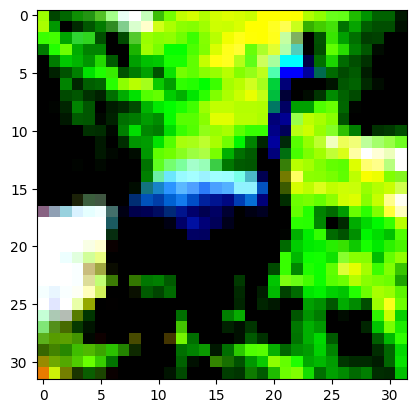

In [84]:
#Veamos como actua en la imagen del ave
img, _ = cifar2[0]
plt.imshow(img.permute(1, 2, 0))
plt.show()

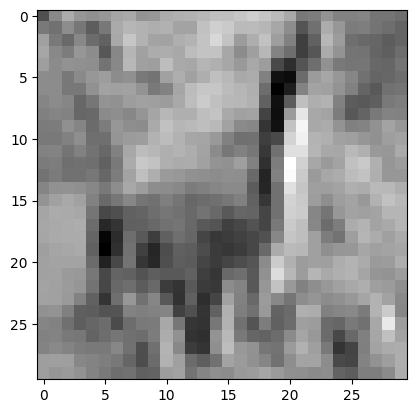

In [85]:
#Veamos una imagen de ave o del label 0
img, _ = cifar2[0]
plt.imshow(output[0, 0].detach(), cmap='gray')
plt.show()

Vemos que se pierden algunos pixeles, pero para añadir los pixeles faltantes se puede usar torch.

In [86]:
#Utilizamos padding dentro de la convolución para preservar el tamaño de la imagen
conv = nn.Conv2d(3, 1, kernel_size=3, padding=1)  #Añade 1 pixel de cada lado y arriba y abajo
output = conv(img.unsqueeze(0))
img.unsqueeze(0).shape, output.shape

(torch.Size([1, 3, 32, 32]), torch.Size([1, 1, 32, 32]))

In [87]:
#Vamos a ve como detectamos caacterísticas con convoluciones
with torch.no_grad():      #Eliminamos el bias
    conv.bias.zero_()
with torch.no_grad():           #Hacemos sus pesos una constante
    conv.weight.fill_(1.0 / 9.0)

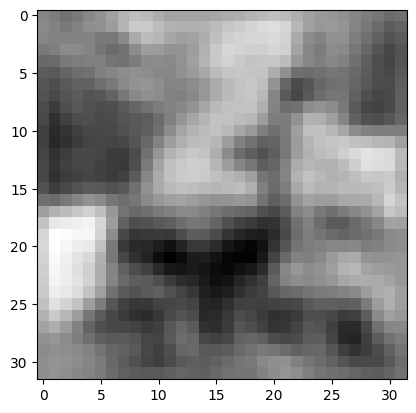

In [88]:
output = conv(img.unsqueeze(0))
plt.imshow(output[0, 0].detach(), cmap='gray')
plt.show()
#Obtenemos una imagen difuminada de la imágen original, como que la suavizo

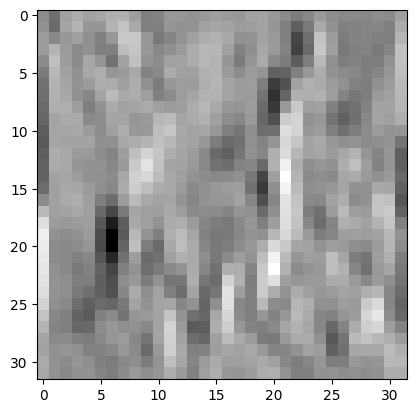

In [90]:
#Este es un kernel que detecta bordes verticales
conv = nn.Conv2d(3, 1, kernel_size=3, padding=1)
with torch.no_grad():
    conv.weight[:] = torch.tensor([[-1.0, 0.0, 1.0],
                                   [-1.0, 0.0, 1.0],
                                   [-1.0, 0.0, 1.0]])
    conv.bias.zero_()

output = conv(img.unsqueeze(0))
plt.imshow(output[0, 0].detach(), cmap='gray')
plt.show()

Vemos que las convoluciones sirven como detectores de las características de una imagen. Con aprendizaje profundo dejamos que los kernels se estimen por los datos de tal forma que la distinción sea la más efectiva:


Una opción, usada en CNN's, es agrupar una convolución después de otra y al mismo tiempo bajando la resolución entre las sucesivas convoluciones. Existen varios métodos como max pooling que consiste en tomar máximos.

In [91]:
#Nuevamene usamos torch nn
pool = nn.MaxPool2d(2)            #El 2 sirve para saber en cuanto dividir cada lado de la imagen
output = pool(img.unsqueeze(0))
img.unsqueeze(0).shape, output.shape

(torch.Size([1, 3, 32, 32]), torch.Size([1, 3, 16, 16]))

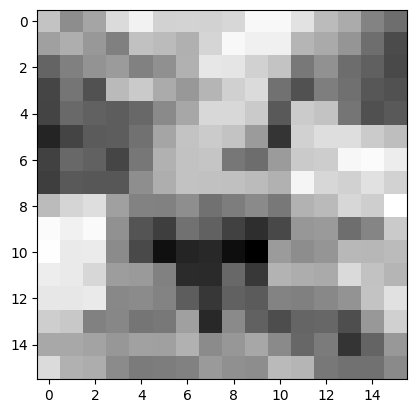

In [92]:
plt.imshow(output[0, 0].detach(), cmap='gray')
plt.show()

In [99]:
#Escribimos el modelo
model = nn.Sequential(                   #Empezamos la parte de convolución y pooling con una imagen 3x32*32
    nn.Conv2d(3, 16, kernel_size=3, padding=1),
    nn.Tanh(),
    nn.MaxPool2d(2),
    nn.Conv2d(16, 8, kernel_size=3, padding=1),
    nn.Tanh(),
    nn.MaxPool2d(2),                      #Terminamos la parte de convolución con un tensor 8x8x8
    nn.Flatten(),                         #Aplanamos a un vector
    nn.Linear(8*8*8, 32),                 #Aplicamos la pare lineal
    nn.Tanh(),
    nn.Linear(32,2))

In [100]:
#Contemos el número de parámetros de este modelo:
numel_list = [p.numel() for p in model.parameters()]
sum(numel_list), numel_list

(18090, [432, 16, 1152, 8, 16384, 32, 64, 2])

In [101]:
model(img.unsqueeze(0))

tensor([[ 0.0592, -0.0216]], grad_fn=<AddmmBackward0>)

In [105]:
#Vamos a escribir la red neuronal como un submodulo
class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.act1 = nn.Tanh()
        self.pool1 = nn.MaxPool2d(2)
        self.conv2 = nn.Conv2d(16, 8, kernel_size=3, padding=1)
        self.act2 = nn.Tanh()
        self.pool2 = nn.MaxPool2d(2)
        self.fc1 = nn.Linear(8*8*8, 32)
        self.act3 = nn.Tanh()
        self.fc2 = nn.Linear(32, 2)

    def forward(self, x):
        out = self.pool1(self.act1(self.conv1(x)))
        out = self.pool2(self.act2(self.conv2(out)))
        out = out.view(-1, 8*8*8)                        #Esto sustituye el flatten que vimos antes
        out = self.act3(self.fc1(out))
        out = self.fc2(out)
        return out

In [106]:
model = Net()
numel_list = [p.numel() for p in model.parameters()]
sum(numel_list), numel_list

(18090, [432, 16, 1152, 8, 16384, 32, 64, 2])

Hemos reducido la cantidad de parámetros a 18 mil, probemos que tal su funcionalidad

In [109]:
#Definamos la función de entrenamiento
import datetime

def training_loop(n_epochs, optimizer, model, loss_fn, train_loader):
    for epoch in range(1, n_epochs+1):
        loss_train = 0.0
        for imgs, labels in train_loader:
            outputs = model(imgs)
            loss = loss_fn(outputs, labels)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            loss_train += loss.item()

        if epoch == 1 or epoch % 10 == 0:
            print('{} Epoch {}, Training loss {}'.format(
                datetime.datetime.now(), epoch, loss_train/len(train_loader)))

In [111]:
train_loader = torch.utils.data.DataLoader(cifar2, batch_size=64, shuffle=True)

model = Net()
optimizer = optim.SGD(model.parameters(), lr=1e-2)
loss_fn = nn.CrossEntropyLoss()

training_loop(
    n_epochs = 100,
    optimizer = optimizer,
    model = model,
    loss_fn = loss_fn,
    train_loader = train_loader
)

2025-10-27 03:09:03.932624 Epoch 1, Training loss 0.5634506253679846
2025-10-27 03:11:36.345897 Epoch 10, Training loss 0.3364561970826167
2025-10-27 03:14:24.378180 Epoch 20, Training loss 0.300584249008613
2025-10-27 03:16:54.317632 Epoch 30, Training loss 0.27392457814732935
2025-10-27 03:19:35.964751 Epoch 40, Training loss 0.25445337531862744
2025-10-27 03:22:30.961835 Epoch 50, Training loss 0.23479882779584568
2025-10-27 03:25:13.415103 Epoch 60, Training loss 0.21542561623700865
2025-10-27 03:28:00.781509 Epoch 70, Training loss 0.20214789583804502
2025-10-27 03:30:49.779306 Epoch 80, Training loss 0.18570058014552304
2025-10-27 03:33:25.985018 Epoch 90, Training loss 0.17160357639288445
2025-10-27 03:35:53.144428 Epoch 100, Training loss 0.15845259373924533


In [112]:
train_loader = torch.utils.data.DataLoader(cifar2, batch_size=64, shuffle=False)
val_loader = torch.utils.data.DataLoader(cifar2_val, batch_size=64, shuffle=False)

def validate(model, train_loader, val_loader):
    for name, loader in [("train", train_loader), ("val", val_loader)]:
        correct = 0
        total = 0

        with torch.no_grad():
            for imgs, labels in loader:
                outputs = model(imgs)
                _, predicted = torch.max(outputs, dim=1)
                total += labels.shape[0]
                correct += int((predicted == labels).sum())

        print("Precisión {}: {:.2f}".format(name, correct/total))

validate(model, train_loader, val_loader)

Precisión train: 0.93
Precisión val: 0.89


In [113]:
torch.save(model.state_dict(), data_path + 'aves_v_aviones.pt')

In [114]:
loaded_model = Net()          #AL cargar el modelo hay que mantener el nombre
loaded_model.load_state_dict(torch.load(data_path + 'aves_v_aviones.pt'))

/tmp/ipykernel_5441/3649752681.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  loaded_model.load_state_dict(torch.load(data_path + 'aves_v_aviones.pt'))


<All keys matched successfully>